#K-medias

K-medias es un algoritmo de agrupamiento utilizado para dividir un conjunto de datos en $k$ grupos o clústeres distintos. El proceso comienza seleccionando aleatoriamente $k$ puntos, llamados *centroides iniciales*, que representarán los centros de los grupos.

Luego, cada punto del conjunto de datos se asigna al centroide más cercano, formando así los $k$ clústeres. Una vez asignados los puntos, el algoritmo recalcula la posición de cada centroide, tomando la media de todos los puntos asignados a ese clúster.

Este proceso de asignación de puntos a centroides y recalculo de posiciones se repite de manera iterativa hasta que los centroides ya no cambian significativamente o hasta que se alcanza un número máximo de iteraciones. El algoritmo finaliza cuando las asignaciones de los puntos permanecen estables entre iteraciones, lo que indica que el agrupamiento ha convergido.

La figura ilustra el funcionamiento del algoritmo k-medias. En la figura a, se muestran 12 puntos que representan las coordenadas de muestras de un problema a analizar. Este conjunto de puntos será utilizado en las siguientes secciones y se denominará *el ejemplo de los doce puntos*.

En la figura b, se presentan tres centroides iniciales ubicados aleatoriamente. Cada punto se asigna al centroide más cercano, bajo la suposición de que tres clústeres son apropiados para este caso. Luego, la nueva posición de los centroides se calcula tomando la media de los puntos asignados a cada uno. En la figura c, se muestra la reasignación de los puntos al centroide más cercano según los nuevos cálculos.

Este proceso se repite de manera iterativa, y los resultados después de cinco iteraciones se muestran en la figura d. En este punto, la asignación de los puntos a cada clúster ya es adecuada, lo que indica que, en este ejemplo sencillo, el número de iteraciones realizado ha sido suficiente para llegar a una solución estable.

<table>
  <tr>
    <td>
      <img src="https://drive.google.com/uc?id=1u540p41WNfhDIXQN1uU1Qdf3kqQCUhUU" width="300" height="250">
    <p>a</p>
    </td>
    <td>
      <img src="https://drive.google.com/uc?id=1vdduVGGMhSmbZ-Ql65PStAlhAMczNale" width="300" height="250">
    <p>b</p>
    </td>
  </tr>
  <tr>
    <td>
      <img src="https://drive.google.com/uc?id=1KE-lj1Rp42ZixmgNsCyjltYADjOWSXUG" width="300" height="250">
    <p>c</p>
    </td>
    <td>
      <img src="https://drive.google.com/uc?id=1QqaLA68VsCMoOLsBY6TzuPc7jD53Z3CI" width="300" height="250">
    <p>d</p>
    </td>
  </tr>
</table>


La selección del número adecuado de clústeres, representado por $k$, es un paso esencial antes de aplicar el algoritmo de k-medias, ya que este parámetro define la cantidad de grupos en los que se dividirá el conjunto de datos.
* Elegir un valor de $k$ demasiado bajo puede generar agrupaciones excesivamente generales, fusionando datos con características distintivas en un solo clúster, lo que ocasiona la pérdida de información importante.
* Seleccionar un valor de $k$ demasiado alto puede conducir a una sobresegmentación, en la que los clústeres capturan variaciones menores o incluso el ruido en los datos, generando una complejidad innecesaria y dificultando la interpretación del modelo.

Para determinar el valor óptimo de $k$, existen diferentes métodos.
* Uno de los más populares es el Método del Codo, que busca el punto en el que la variación dentro de los clústeres deja de disminuir de forma significativa, indicando que se ha alcanzado un número adecuado de grupos.
* Otro enfoque es el Índice de Silueta, que evalúa la calidad de la agrupación midiendo la proximidad de los puntos dentro de un clúster y su separación de otros clústeres.

También pueden usarse diferentes métricas para calcular la proximidad entre los puntos de datos y los centroides como:
* La distancia euclidiana
* La distancia de Manhattan
* La distancia de Minkowski
* El producto interno o el producto cruz.

La elección de la métrica adecuada dependerá de la naturaleza de los datos y de los objetivos específicos del problema, y puede influir en la precisión y la interpretabilidad de los clústeres resultantes.

Si bien k-medias es conocido por su simplicidad y eficiencia, también presenta algunas limitaciones:
* Su sensibilidad a la selección inicial de los centroides
* Su dificultad para manejar clústeres que tienen tamaños o densidades muy diferentes.

A pesar de estas limitaciones, su capacidad para manejar grandes volúmenes de datos y su facilidad de uso lo hacen una herramienta valiosa en el análisis de datos.


# Aplicando k-medias en la NFL

Comenzamos importando algunas de las bibliotecas que emplearemos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

A continuación:
* Activamos la unidad $\textit{Drive}$.
* Empleamos la biblioteca Pandas para leer y guardar la información del archivo $NFL\_Filtrado.csv$ en un $Dataframe$, $\textit{df}$.

In [ ]:
# Enlace del archivo CSV en Google Drive
ruta_csv = "/content/drive/MyDrive/Inteligencia Artificial Aplicada/Clustering/NFL_Filtrado.csv"

# Cargar el archivo CSV en un DataFrame de Pandas
df = pd.read_csv(ruta_csv)

#Imprimir la información del dataframe
print(df.head())

   Height (inches)  Weight (lbs) Position
0               77           305       DE
1               72           210       DB
2               74           190       CB
3               74           208       CB
4               72           212       FS


#Normalización
Ahora es necesario preparar los datos antes de aplicar cualquier algoritmo de clustering.

Importamos la clase $\textit{MinMaxScaler}$ desde el módulo $\textit{preprocessing}$ de la biblioteca $\texttt{scikit-learn}$, para normalizar los datos.

La normalización es crucial, ya que los algoritmos de clustering son sensibles a la escala de las variables.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Extraer las columnas de altura y peso
X = df[['Height (inches)', 'Weight (lbs)']]

# Normalizar los datos
scaler = MinMaxScaler()
X_normalizado = scaler.fit_transform(X)
print(X_normalizado)

[[0.71428571 0.71359223]
 [0.35714286 0.25242718]
 [0.5        0.15533981]
 ...
 [0.42857143 0.22815534]
 [0.42857143 0.14563107]
 [0.85714286 0.62621359]]


Listo, estamos en condiciones para aplicar k-medias, para lo cual importamos la clase $\textit{KMeans}$ desde el módulo $\textit{cluster}$ de la biblioteca $\texttt{scikit-learn}$.

De acuerdo a lo mencionado para este ejemplo vamos a considerar dos clústeres, $k=2$.


In [ ]:
from sklearn.cluster import KMeans

In [ ]:
# Definir el número de clústeres
kmeans = KMeans(n_clusters=2, random_state=42)

# Ajustar el modelo a los datos
kmeans.fit(X_normalizado)

# Obtener las etiquetas de los clústeres
df['KMedias_Clusters'] = kmeans.labels_
df.head()

,Height (inches),Weight (lbs),Position,KMedias_Clusters
0,77,305,DE,0
1,72,210,DB,1
2,74,190,CB,1
3,74,208,CB,1
4,72,212,FS,1


Para visualizar los resultados del clustering, podemos utilizar un diagrama de dispersión coloreado según las etiquetas de los clústeres.

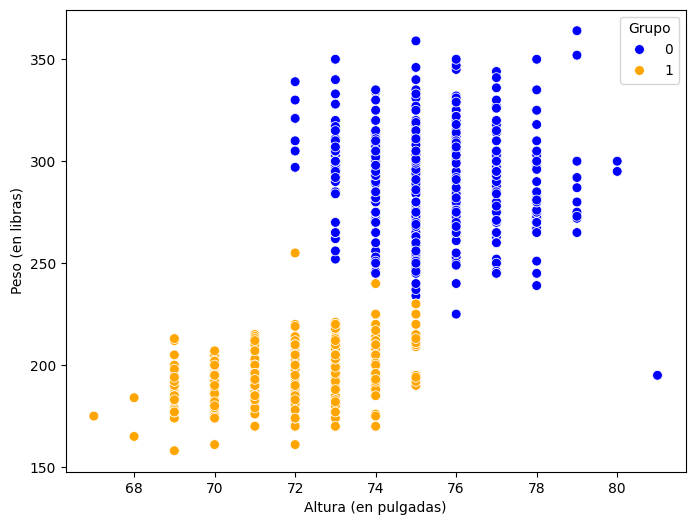

In [ ]:
# Crear el diagrama de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Height (inches)', y='Weight (lbs)', hue='KMedias_Clusters', palette={0: 'blue', 1: 'orange'}, s=50, edgecolor='w')

# Configurar el título y las etiquetas
plt.xlabel('Altura (en pulgadas)')
plt.ylabel('Peso (en libras)')
plt.legend(title='Grupo', loc='upper right')

# Mostrar el gráfico
plt.show()

Observa que la mayoría de las muestras han sido correctamente clasificadas; sin embargo, se identifican errores en algunos puntos situados en la frontera entre los clústeres.

Es importante tener en cuenta que estos errores de clasificación pueden ser normales en ciertos problemas y que lograr una precisión del 100\% es a menudo inalcanzable, incluso para expertos en el área.


# Índice silueta
Calculemos el índice silueta para los clústeres formados.

In [ ]:
from sklearn.metrics import silhouette_score

In [ ]:
# Calcular el Índice de Silueta
score = silhouette_score(X_normalizado, kmeans.labels_)
print(f"Índice de Silueta: {score}")

Índice de Silueta: 0.6585205681134002
